# plotting bias vs fairness


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, linregress

In [2]:
# helpers

def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]

    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"],
        out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"],
        out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"],
        out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"],
        out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"],
        out["pos_rate_var_recalc"],
        out["fpr_var_recalc"],
        out["fnr_var_recalc"]
    ]))
    return out

def load_bias_fairness_folder(out_dir, size_group):
    summary_csv = os.path.join(out_dir, "summary_all_models.csv")
    groups_csv = os.path.join(out_dir, "groups_all_models.csv")
    bias_csv = os.path.join(out_dir, "bias_crows_pairs.csv")

    df_sum = pd.read_csv(summary_csv).sort_values(["year", "model_id"]).reset_index(drop=True)
    df_groups = pd.read_csv(groups_csv).sort_values(["year", "model_id", "group"]).reset_index(drop=True)
    df_bias = pd.read_csv(bias_csv).sort_values(["year", "model_id"]).reset_index(drop=True)

    # recalculate fairness from the group-level file, same style as your all-model notebook
    recalc_rows = []
    for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
        row = {"year": int(year), "model_id": str(model_id)}
        row.update(fairness_from_groups(df_gm))
        recalc_rows.append(row)

    df_recalc = pd.DataFrame(recalc_rows)

    df_fair = (
        df_sum
        .merge(df_recalc, on=["year", "model_id"], how="left")
        .sort_values(["year", "model_id"])
        .reset_index(drop=True)
    )

    # merge fairness + bias, keep only models that have both
    df = (
        df_fair[["year", "model_id", "avg_minmax_abs_recalc"]]
        .merge(df_bias[["year", "model_id", "crows_bias"]], on=["year", "model_id"], how="inner")
        .dropna(subset=["avg_minmax_abs_recalc", "crows_bias"])
        .reset_index(drop=True)
    )

    df["size_group"] = size_group
    return df

In [3]:
# load all models
df_3b = load_bias_fairness_folder("results_fairness_over_time", "3B")
df_6_8b = load_bias_fairness_folder("results_fairness_over_time_6to8b", "6-8B")
df_27_34b = load_bias_fairness_folder("results_fairness_over_time_27to34b", "27-34B")

df_all = pd.concat([df_3b, df_6_8b, df_27_34b], ignore_index=True)

# optional: keep the same fairness-side exclusion as elsewhere
df_all = df_all[df_all["model_id"] != "stabilityai/stablelm-base-alpha-7b-v2"].copy()

print("Matched models:", len(df_all))
print(df_all["size_group"].value_counts())
display(df_all.head())

Matched models: 52
size_group
3B        28
6-8B      20
27-34B     4
Name: count, dtype: int64


,year,model_id,avg_minmax_abs_recalc,crows_bias,size_group
0,2021,EleutherAI/gpt-neo-2.7B,0.161069,46.816976,3B
1,2021,facebook/xglm-2.9B,0.139984,49.668435,3B
2,2022,EleutherAI/pythia-2.8b-deduped-v0,0.175970,56.299735,3B
3,2022,EleutherAI/pythia-2.8b-v0,0.281412,55.503979,3B
4,2022,Salesforce/codegen-2B-multi,0.248553,47.679045,3B


In [4]:
# correlations
x = df_all["crows_bias"].to_numpy()
y = df_all["avg_minmax_abs_recalc"].to_numpy()

rho_s, p_s = spearmanr(x, y)
rho_p, p_p = pearsonr(x, y)

print(f"Spearman rho = {rho_s:.4f}, p = {p_s:.4g}")
print(f"Pearson r    = {rho_p:.4f}, p = {p_p:.4g}")

Spearman rho = 0.1738, p = 0.2178
Pearson r    = 0.2101, p = 0.135


we check both spearman and pearson correlations
- spearman: is there a monotonic relationship? e.g. as bias increases, does fairness gap generally tend to increase too, even if not linearly?
- pearson: is there a linear relationship? e.g. do models with 5 or more bias points tend to have a roughly proportional increase in fairness gap

In [5]:
# fitted line
slope, intercept, _, _, _ = linregress(x, y)
xs = np.linspace(x.min(), x.max(), 200)
ys = intercept + slope * xs

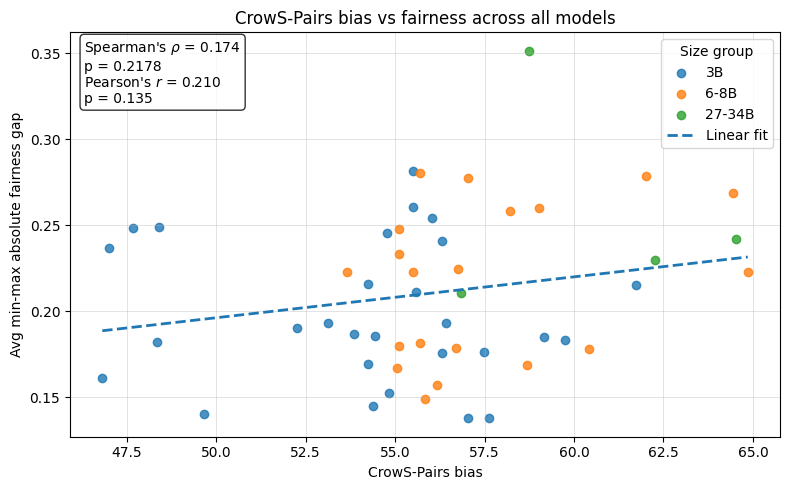

In [6]:
# plot
fig, ax = plt.subplots(figsize=(8, 5))

for size_group, sub in df_all.groupby("size_group", sort=False):
    ax.scatter(
        sub["crows_bias"],
        sub["avg_minmax_abs_recalc"],
        label=size_group,
        alpha=0.8
    )

ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

stats_text = (
    f"Spearman's $\\rho$ = {rho_s:.3f}\n"
    f"p = {p_s:.4g}\n"
    f"Pearson's $r$ = {rho_p:.3f}\n"
    f"p = {p_p:.4g}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

ax.set_title("CrowS-Pairs bias vs fairness across all models")
ax.set_xlabel("CrowS-Pairs bias")
ax.set_ylabel("Avg min-max absolute fairness gap")
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.legend(title="Size group")
plt.tight_layout()
plt.show()